In [3]:
import tensorflow as tf
import tensorflow_datasets as tfds
dataset, info = tfds.load("tf_flowers", as_supervised=True, with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /home/prince/tensorflow_datasets/tf_flowers/incomplete.VJD5QN_3.0.1/tf_flowers-train.tfrecord*...:  …

Dataset tf_flowers downloaded and prepared to /home/prince/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


2026-05-02 15:46:47.173904: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
dataset_size = info.splits["train"].num_examples   
class_names = info.features["label"].names        
n_classes = info.features["label"].num_classes    

In [7]:
test_set_raw, valid_set_raw, train_set_raw = tfds.load(
    "tf_flowers",
    split=["train[:10%]", "train[10%:25%]", "train[25%:]"],
    as_supervised=True)

In [8]:
batch_size = 32
preprocess = tf.keras.Sequential([
    tf.keras.layers.Resizing(height=224, width=224, crop_to_aspect_ratio=True),
    tf.keras.layers.Lambda(tf.keras.applications.xception.preprocess_input)
])

In [9]:
train_set = train_set_raw.map(lambda X, y: (preprocess(X), y))
train_set = train_set.shuffle(1000, seed=42).batch(batch_size).prefetch(1)

In [17]:
valid_set = valid_set_raw.map(lambda X, y: (preprocess(X), y))
valid_set = valid_set.batch(batch_size).prefetch(1)
test_set = test_set_raw.map(lambda X, y: (preprocess(X), y))
test_set = test_set.batch(batch_size).prefetch(1)

In [10]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(mode="horizontal", seed=42),
    tf.keras.layers.RandomRotation(factor=0.05, seed=42),
    tf.keras.layers.RandomContrast(factor=0.2, seed=42)
])

In [14]:
base_model = tf.keras.applications.xception.Xception(weights="imagenet", include_top=False)
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
output = tf.keras.layers.Dense(n_classes, activation="softmax")(avg)
model = tf.keras.Model(inputs=base_model.input, outputs=output)

In [15]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
# optimizer = tf.keras.optimizers.SGD(learning_rate=0.1,
# momentum=0.9)
# model.compile(loss="sparse_categorical_crossentropy",
# optimizer=optimizer,
# metrics=["accuracy"])
# history = model.fit(train_set, validation_data=valid_set,
# epochs=3)

Epoch 1/3


86/86 ━━━━━━━━━━━━━━━━━━━━ 570s 7s/step - accuracy: 0.9499 - loss: 0.1663 - val_accuracy: 0.8530 - val_loss: 0.6766
Epoch 2/3
12/86 ━━━━━━━━━━━━━━━━━━━━ 7:06 6s/step - accuracy: 0.9515 - loss: 0.1055

KeyboardInterrupt: 

In [ ]:
# for layer in base_model.layers[56:]:
#     layer.trainable = True

# optimizer = tf.keras.optimizers.SGD(learning_rate=0.01,
# momentum=0.9)

# model.compile(loss="sparse_categorical_crossentropy",
# optimizer=optimizer,
# metrics=["accuracy"])
# history = model.fit(train_set, validation_data=valid_set,
# epochs=10)

In [21]:
model = tf.keras.models.load_model("/media/prince/5A4E832F4E83034D/DL-foundation/models/flower_detection.h5")

2026-05-02 16:44:15.819057: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


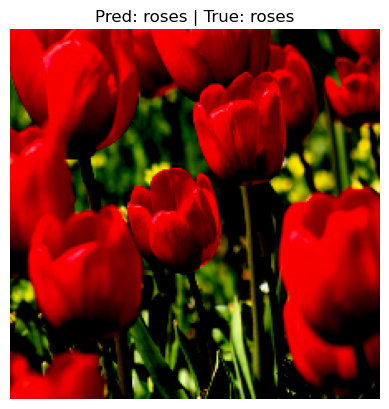

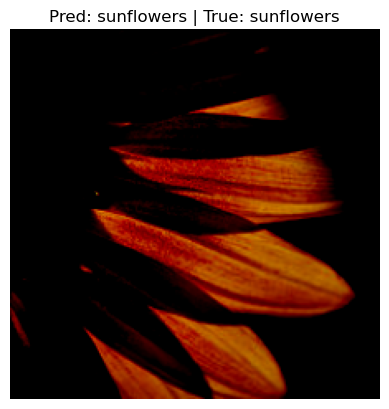

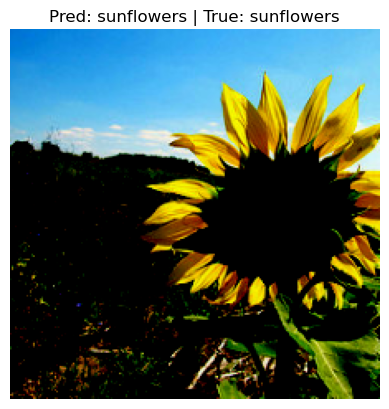

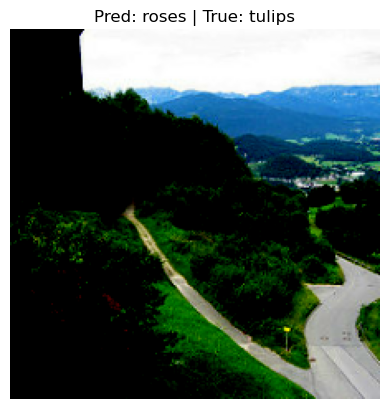

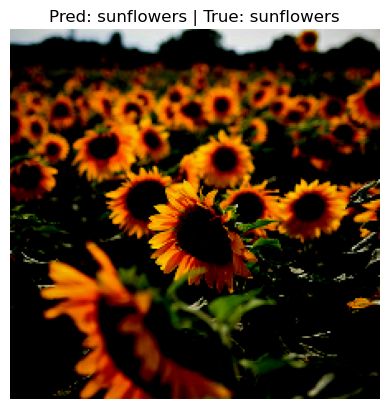

In [22]:
import matplotlib.pyplot as plt

images, true_labels = next(iter(test_set))
preds = tf.argmax(model.predict(images), axis=1).numpy()

# 5. Class names for tf_flowers
class_names = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

# 6. Show first 5 images with predictions
for i in range(5):
    plt.imshow(images[i])  # shows preprocessed image (values -1..1, may look odd but okay)
    plt.axis('off')
    plt.title(f"Pred: {class_names[preds[i]]} | True: {class_names[true_labels[i].numpy()]}")
    plt.show()